In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("Tables/train.csv", index_col="PassengerId")
test = pd.read_csv("Tables/test.csv", index_col="PassengerId")

In [3]:
# Beide Indizes (PassengerId) kombinieren
all_groups = train.index.append(test.index).str.split("_").str[0]

# Gruppengröße über kombinierte Daten berechnen
group_sizes = all_groups.value_counts()

# Zurück auf train und test mappen
train["Group"] = train.index.str.split("_").str[0]
train["GroupSize"] = train["Group"].map(group_sizes)

test["Group"] = test.index.str.split("_").str[0]
test["GroupSize"] = test["Group"].map(group_sizes)

In [4]:
split_cols = train["Cabin"].str.split("/", expand=True)

train["Deck"] = split_cols[0]
train["Num"] = split_cols[1].astype(float)  # float wegen NaNs
train["Side"] = split_cols[2]

split_cols = test["Cabin"].str.split("/", expand=True)

test["Deck"] = split_cols[0]
test["Num"] = split_cols[1].astype(float)  # float wegen NaNs
test["Side"] = split_cols[2]

In [5]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

train["Expenses"] = train[spend_cols].sum(axis=1)
test["Expenses"] = test[spend_cols].sum(axis=1)

In [7]:
train[["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]].isna().sum()

RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
dtype: int64

<Axes: xlabel='Deck'>

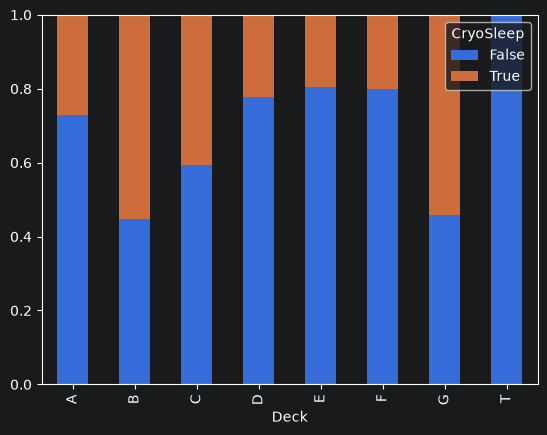

In [11]:
pd.crosstab(train["Deck"], train["CryoSleep"], normalize="index").plot(kind="bar", stacked=True)

In [9]:
train = train.drop(columns=["Cabin","RoomService","FoodCourt","ShoppingMall","Spa","VRDeck", "Group", "Name"])
test = test.drop(columns=["Cabin","RoomService","FoodCourt","ShoppingMall","Spa","VRDeck", "Group", "Name"])

In [10]:
train.to_csv("Train.csv")
test.to_csv("Test.csv")